In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)


In [2]:
np.random.seed(42)
n_samples = 1000

# Continuous Features
age = np.random.normal(38, 10, n_samples).astype(int)
income = np.random.exponential(scale=50000, size=n_samples) + 20000
credit_score = np.random.randint(300, 850, n_samples)

# Make Skill Wallet Balance heavily dependent on Income and Age
skill_balance = (income * 0.01) + (age * 5) + np.random.normal(200, 100, n_samples)
skill_balance = np.clip(skill_balance, 0, None)  # No negative balances

# Categorical Features
employment = np.random.choice(['Employed', 'Self-Employed', 'Freelancer', 'Unemployed'], size=n_samples, p=[0.6, 0.2, 0.15, 0.05])
education = np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], size=n_samples, p=[0.2, 0.5, 0.2, 0.1])

# Make Approval Status dependent on combinations of features (Multivariate Logic)
log_odds = (credit_score - 600) * 0.02 + (income / 30000) + (skill_balance / 200) - 2
probs = 1 / (1 + np.exp(-log_odds))
approval = np.where(probs > np.random.uniform(0, 1, n_samples), 1, 0)

df = pd.DataFrame({
    'Applicant_Age': age,
    'Annual_Income': income,
    'Credit_Score': credit_score,
    'Skill_Wallet_Balance': skill_balance,
    'Employment_Status': employment,
    'Education_Level': education,
    'Approval_Status': approval
})

print("Dataset successfully generated. Rows:", df.shape[0], "Columns:", df.shape[1])
print("\n")



Dataset successfully generated. Rows: 1000 Columns: 7




--- Calculating Feature Correlation Matrix ---
                      Applicant_Age  Annual_Income  Credit_Score  \
Applicant_Age                 1.000         -0.010         0.035   
Annual_Income                -0.010          1.000        -0.001   
Credit_Score                  0.035         -0.001         1.000   
Skill_Wallet_Balance          0.094          0.974        -0.009   
Approval_Status               0.057          0.267         0.466   

                      Skill_Wallet_Balance  Approval_Status  
Applicant_Age                        0.094            0.057  
Annual_Income                        0.974            0.267  
Credit_Score                        -0.009            0.466  
Skill_Wallet_Balance                 1.000            0.284  
Approval_Status                      0.284            1.000  




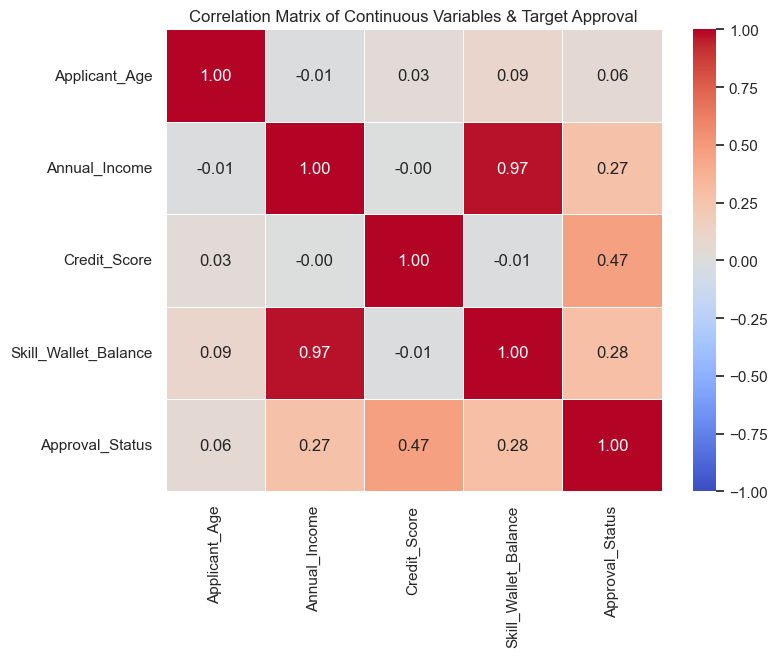

In [3]:
print("--- Calculating Feature Correlation Matrix ---")
num_cols = ['Applicant_Age', 'Annual_Income', 'Credit_Score', 'Skill_Wallet_Balance', 'Approval_Status']
corr_matrix = df[num_cols].corr()
print(corr_matrix.round(3))
print("\n")

# Visualizing Correlations with a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Continuous Variables & Target Approval')
plt.show()

--- Generating Multi-Variable Pairplot ---


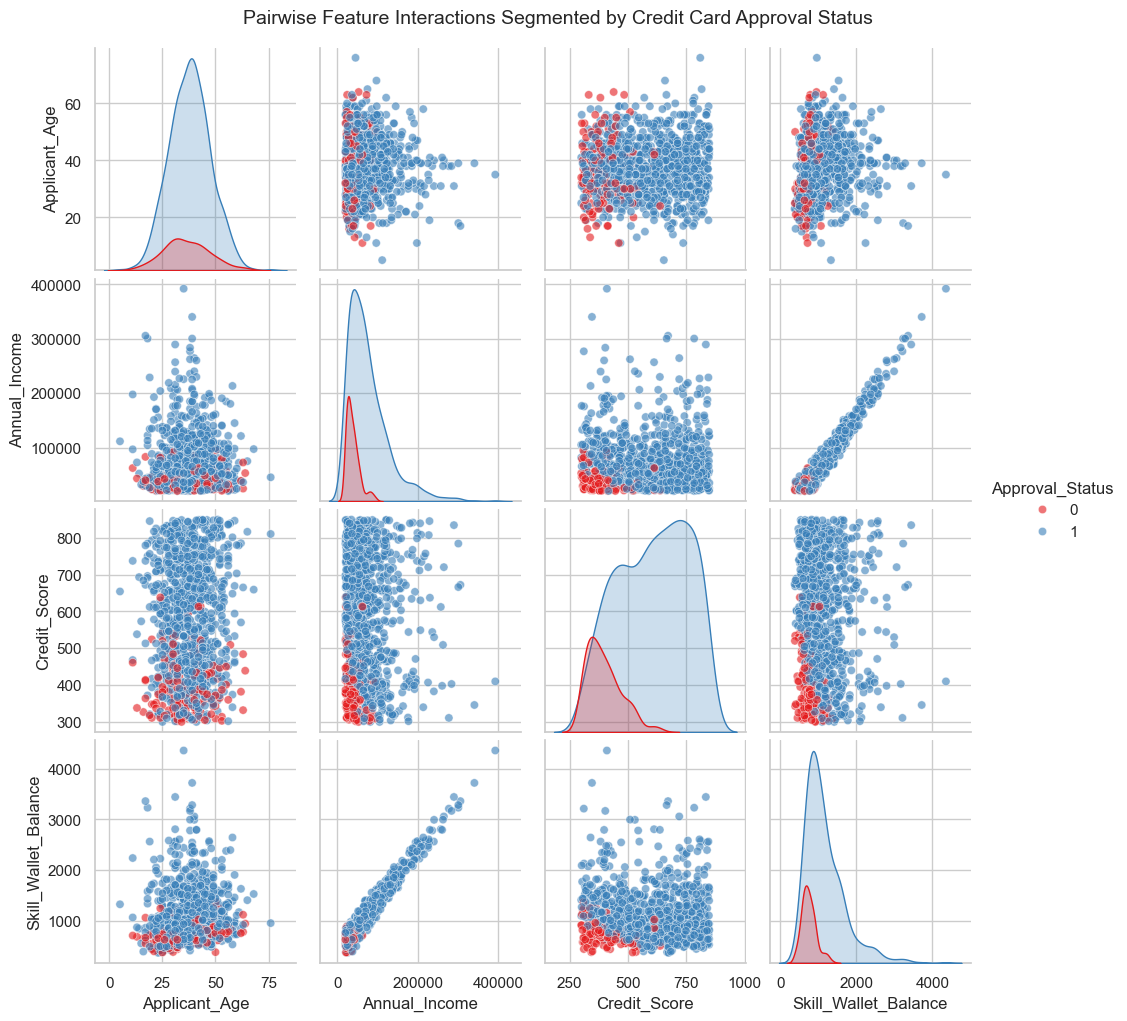

In [4]:
print("--- Generating Multi-Variable Pairplot ---")
pair_plot = sns.pairplot(df[num_cols], hue='Approval_Status', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.6})
pair_plot.fig.suptitle('Pairwise Feature Interactions Segmented by Credit Card Approval Status', y=1.02, fontsize=14)
plt.show()